In [1]:
import sys
print(sys.version)

3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:26:47) [MSC v.1942 64 bit (AMD64)]


In [5]:
import pandas as pd  

import numpy as np  

import matplotlib.pyplot as plt  

import seaborn as sns 
from sklearn.datasets import load_breast_cancer  

print("Packages imported successfully.") 

Packages imported successfully.


# Exploratory Breast Cancer Diagnostic Data Analysis 
 
**Author:** Akash Bhardwaj   
**Date:** July 2026   
**Dataset:** Breast Cancer Wisconsin (Diagnostic) — loaded via scikit-learn   
**Purpose:** Educational exploratory data analysis and introductory classification workflow 


In [6]:
# Import required packages 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import load_breast_cancer 
 
print("All packages imported successfully.")

All packages imported successfully.


In [7]:
# Load the Breast Cancer Wisconsin (Diagnostic) dataset 
cancer_data = load_breast_cancer() 
 
# Inspect what the dataset object contains 
print("Dataset keys:") 
print(cancer_data.keys()) 
 

Dataset keys:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [8]:
# Print the official dataset description 
print(cancer_data.DESCR) 


.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [9]:
# Create a pandas DataFrame from the dataset 
df = pd.DataFrame( 
   data=cancer_data.data, 
   columns=cancer_data.feature_names 
) 
 
# Add the target column 
# 0 = malignant, 1 = benign 
df["diagnosis"] = cancer_data.target 
 
# Map numeric labels to readable names 
df["diagnosis_label"] = df["diagnosis"].map( 
  {0: "Malignant", 1: "Benign"} 
) 
 
# Inspect the first five rows 
print("Shape:", df.shape) 
print() 
print(df.head()) 


Shape: (569, 32)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst perimeter  worst area  worst smoothn

In [10]:
# Check for missing values 
print("Missing values per column:") 
print(df.isnull().sum()) 
print() 
 
# Check data types 
print("Data types:") 
print(df.dtypes) 
print() 
 
# Check class distribution 
print("Diagnosis class distribution:") 
print(df["diagnosis_label"].value_counts()) 


Missing values per column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnosis                  0
diagnosis_label            0
dtype: int64

Data types:
mean radius        

In [11]:
import os 
 
# Create output folders if they do not exist 
os.makedirs("../data_processed", exist_ok=True) 
os.makedirs("../outputs/tables", exist_ok=True) 
os.makedirs("../outputs/figures", exist_ok=True) 
 
# Save the full DataFrame 
df.to_csv( 
   "../data_processed/breast_cancer_dataframe.csv", 
   index=False 
) 
 
# Save a class-distribution summary 
class_distribution = df["diagnosis_label"].value_counts().reset_index() 
class_distribution.columns = ["diagnosis", "count"] 
class_distribution.to_csv( 
   "../outputs/tables/class_distribution.csv", 
   index=False 
) 
 
print("Files saved successfully.") 


Files saved successfully.


In [12]:
# Descriptive statistics for all numeric features 
desc_stats = df.describe().T 
 
print(desc_stats.head(10)) 
 
# Save descriptive statistics 
desc_stats.to_csv( 
   "../outputs/tables/descriptive_statistics.csv" 
) 
 
print() 
print("Descriptive statistics saved.") 


                        count        mean         std        min        25%  \
mean radius             569.0   14.127292    3.524049    6.98100   11.70000   
mean texture            569.0   19.289649    4.301036    9.71000   16.17000   
mean perimeter          569.0   91.969033   24.298981   43.79000   75.17000   
mean area               569.0  654.889104  351.914129  143.50000  420.30000   
mean smoothness         569.0    0.096360    0.014064    0.05263    0.08637   
mean compactness        569.0    0.104341    0.052813    0.01938    0.06492   
mean concavity          569.0    0.088799    0.079720    0.00000    0.02956   
mean concave points     569.0    0.048919    0.038803    0.00000    0.02031   
mean symmetry           569.0    0.181162    0.027414    0.10600    0.16190   
mean fractal dimension  569.0    0.062798    0.007060    0.04996    0.05770   

                              50%        75%         max  
mean radius              13.37000   15.78000    28.11000  
mean texture

C:\Users\Akash Bhardwaj\AppData\Local\Temp\ipykernel_19368\788287293.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


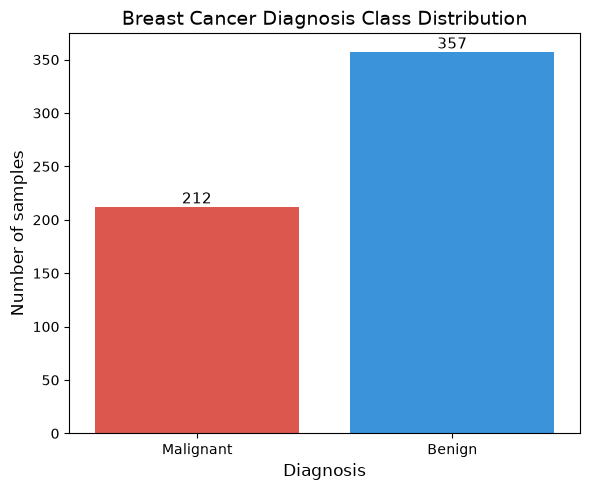

Class distribution plot saved.


In [13]:
# Class distribution bar chart 
fig, ax = plt.subplots(figsize=(6, 5)) 
 
sns.countplot( 
   data=df, 
   x="diagnosis_label", 
   palette={"Benign": "#2196F3", "Malignant": "#F44336"}, 
   ax=ax 
) 
 
ax.set_title("Breast Cancer Diagnosis Class Distribution", fontsize=14) 
ax.set_xlabel("Diagnosis", fontsize=12) 
ax.set_ylabel("Number of samples", fontsize=12) 
 
# Add count labels on bars 
for container in ax.containers: 
   ax.bar_label(container, fontsize=11) 
 
plt.tight_layout() 
plt.savefig( 
   "../outputs/figures/class_distribution_barplot.png", 
   dpi=300 
) 
plt.show() 
 
print("Class distribution plot saved.") 
 

C:\Users\Akash Bhardwaj\AppData\Local\Temp\ipykernel_19368\3940235413.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Akash Bhardwaj\AppData\Local\Temp\ipykernel_19368\3940235413.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Akash Bhardwaj\AppData\Local\Temp\ipykernel_19368\3940235413.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Akash Bhardwaj\AppData\Local\Temp\ipykernel_19368\3940235413.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0

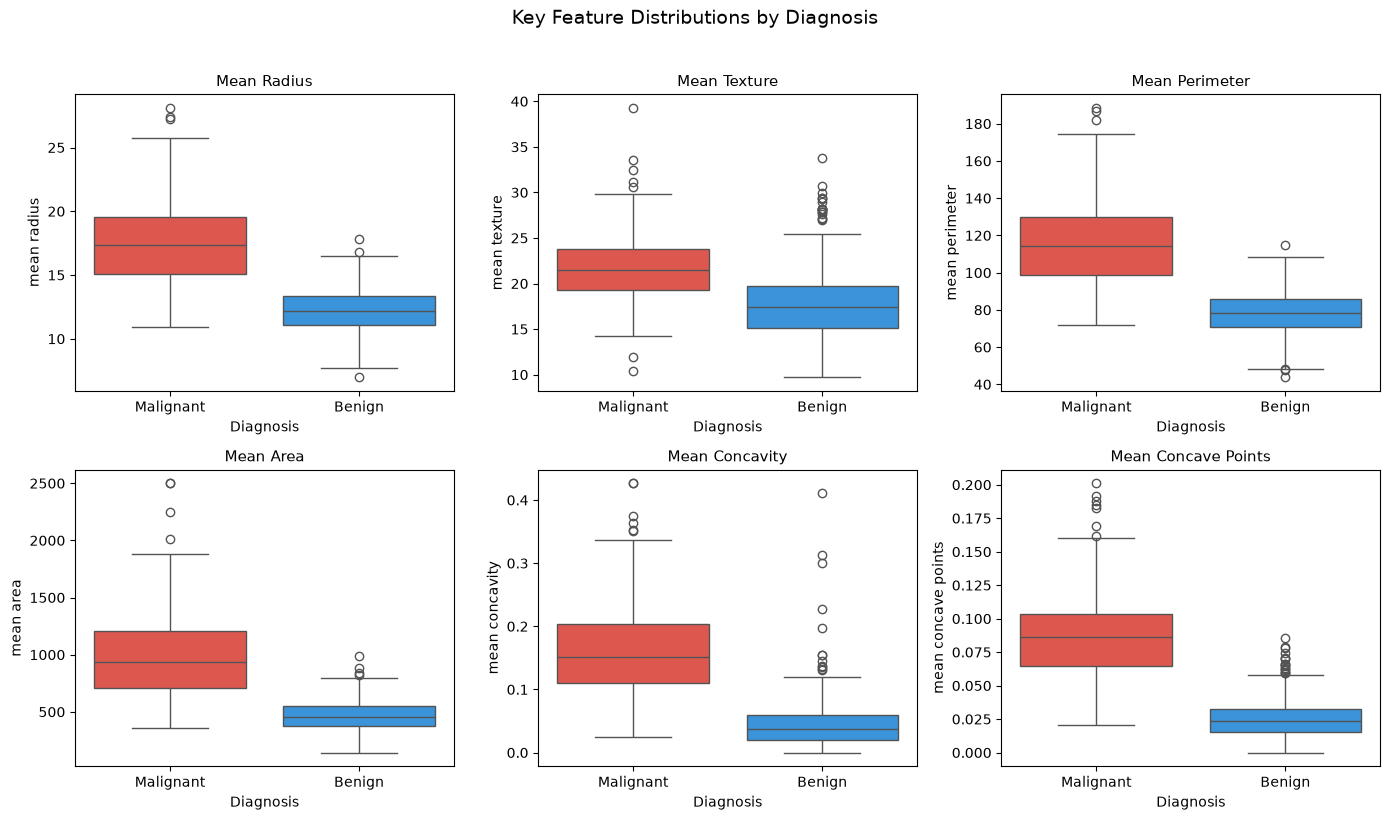

Key features boxplot saved.


In [14]:
# Select key features to visualise 
key_features = [ 
   "mean radius", 
   "mean texture", 
   "mean perimeter", 
   "mean area", 
   "mean concavity", 
   "mean concave points" 
] 
 
fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.flatten() 
 
for i, feature in enumerate(key_features): 
   sns.boxplot( 
       data=df, 
       x="diagnosis_label", 
       y=feature, 
       palette={"Benign": "#2196F3", "Malignant": "#F44336"}, 
       ax=axes[i] 
   ) 
   axes[i].set_title(feature.title(), fontsize=11) 
   axes[i].set_xlabel("Diagnosis", fontsize=10) 
   axes[i].set_ylabel(feature, fontsize=10) 
 
plt.suptitle( 
   "Key Feature Distributions by Diagnosis", 
   fontsize=14, 
   y=1.02 
) 
plt.tight_layout() 
plt.savefig( 
   "../outputs/figures/key_features_boxplots.png", 
   dpi=300, 
   bbox_inches="tight" 
) 
plt.show() 
 
print("Key features boxplot saved.")

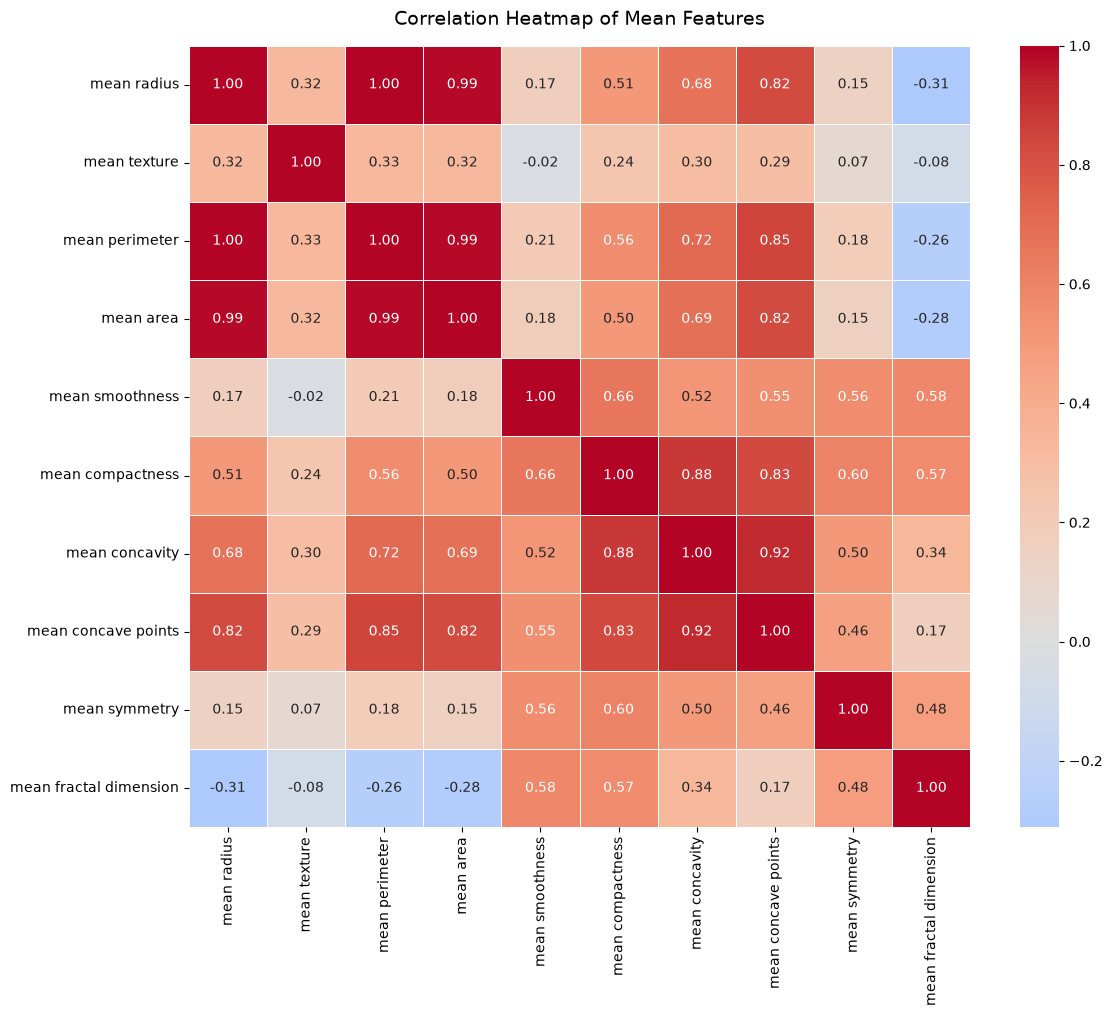

Correlation heatmap saved.


In [15]:
# Select only the mean features for correlation analysis 
mean_features = [col for col in df.columns if col.startswith("mean")] 
 
correlation_matrix = df[mean_features].corr() 
 
fig, ax = plt.subplots(figsize=(12, 10)) 
 
sns.heatmap( 
   correlation_matrix, 
   annot=True, 
   fmt=".2f", 
   cmap="coolwarm", 
   center=0, 
   square=True, 
   linewidths=0.5, 
   ax=ax 
) 
 
ax.set_title( 
   "Correlation Heatmap of Mean Features", 
   fontsize=14, 
   pad=15 
) 
 
plt.tight_layout() 
plt.savefig( 
   "../outputs/figures/mean_features_correlation_heatmap.png", 
   dpi=300, 
   bbox_inches="tight" 
) 
plt.show() 
 
print("Correlation heatmap saved.") 


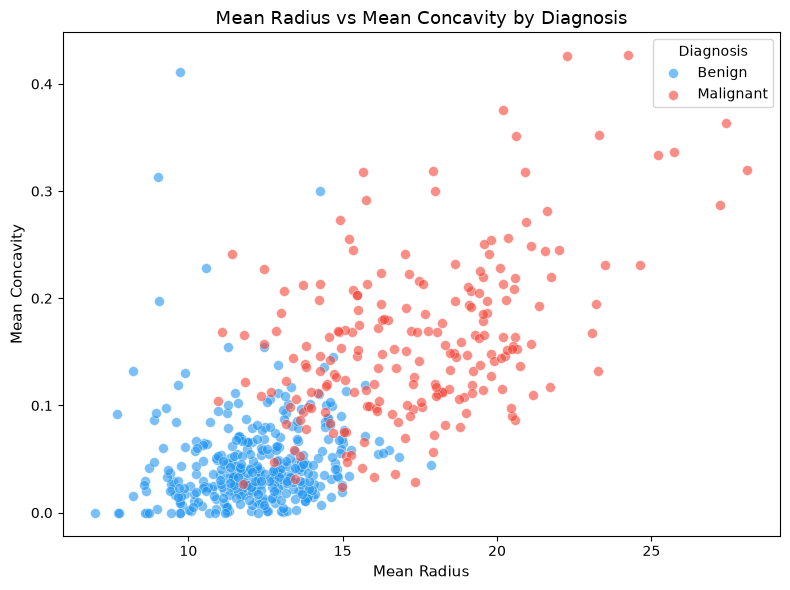

Scatter plot saved.


In [18]:
# Scatter plot of two key features coloured by diagnosis 
fig, ax = plt.subplots(figsize=(8, 6)) 
 
for label, color in zip(["Benign", "Malignant"], ["#2196F3", "#F44336"]): 
   subset = df[df["diagnosis_label"] == label] 
   ax.scatter( 
       subset["mean radius"], 
       subset["mean concavity"], 
       label=label, 
       color=color, 
       alpha=0.6, 
       edgecolors="white", 
       linewidth=0.4, 
       s=50 
   ) 
 
ax.set_title( 
   "Mean Radius vs Mean Concavity by Diagnosis", 
   fontsize=13 
) 
ax.set_xlabel("Mean Radius", fontsize=11) 
ax.set_ylabel("Mean Concavity", fontsize=11) 
ax.legend(title="Diagnosis", fontsize=10) 
 
plt.tight_layout() 
plt.savefig( 
   "../outputs/figures/radius_vs_concavity_scatter.png", 
   dpi=300 
) 
plt.show() 
 
print("Scatter plot saved.") 


## Introductory Classification: Logistic Regression 
 
This section demonstrates a basic logistic regression workflow using the breast cancer diagnostic features. The purpose is to illustrate a reproducible machine-learning pipeline, not to build a clinical prediction tool. 
 
**Important:** This is an educational demonstration using a historic public dataset. Results must not be interpreted as clinical evidence or used for medical decision-making. 


In [19]:
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
 
# Separate features and target 
X = df.drop(columns=["diagnosis", "diagnosis_label"]) 
y = df["diagnosis"] 
 
# Check shapes 
print("Feature matrix shape:", X.shape) 
print("Target vector shape:", y.shape) 
print() 
print("Class distribution in target:") 
print(y.value_counts()) 
 

Feature matrix shape: (569, 30)
Target vector shape: (569,)

Class distribution in target:
diagnosis
1    357
0    212
Name: count, dtype: int64


In [20]:
# Split data into 80% training and 20% test sets 
# random_state ensures reproducibility 
X_train, X_test, y_train, y_test = train_test_split( 
   X, 
   y, 
   test_size=0.20, 
   random_state=42, 
   stratify=y 
) 
 
print("Training set size:", X_train.shape) 
print("Test set size:", X_test.shape) 
print() 
print("Training set class distribution:") 
print(y_train.value_counts()) 
print() 
print("Test set class distribution:") 
print(y_test.value_counts())

Training set size: (455, 30)
Test set size: (114, 30)

Training set class distribution:
diagnosis
1    285
0    170
Name: count, dtype: int64

Test set class distribution:
diagnosis
1    72
0    42
Name: count, dtype: int64


In [21]:
# Standardise features to have mean 0 and standard deviation 1 
# This is important for logistic regression 
scaler = StandardScaler() 
 
# Fit the scaler on training data only 
# Apply the same transformation to test data 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 
 
print("Feature scaling complete.") 
print("Training set mean after scaling (first feature):", 
     round(X_train_scaled[:, 0].mean(), 4)) 
print("Training set std after scaling (first feature):", 
     round(X_train_scaled[:, 0].std(), 4)) 


Feature scaling complete.
Training set mean after scaling (first feature): -0.0
Training set std after scaling (first feature): 1.0


In [22]:
from sklearn.linear_model import LogisticRegression 
 
# Train logistic regression model 
# max_iter increased to ensure convergence 
model = LogisticRegression( 
   random_state=42, 
   max_iter=10000 
) 
 
model.fit(X_train_scaled, y_train) 
 
print("Logistic regression model trained successfully.") 


Logistic regression model trained successfully.


In [23]:
from sklearn.metrics import ( 
   accuracy_score, 
   classification_report, 
   confusion_matrix 
) 
 
# Generate predictions on the test set 
y_pred = model.predict(X_test_scaled) 
 
# Calculate accuracy 
accuracy = accuracy_score(y_test, y_pred) 
 
print("Test set accuracy:", round(accuracy, 4)) 
print() 
print("Classification report:") 
print(classification_report( 
   y_test, 
   y_pred, 
   target_names=["Malignant", "Benign"] 
)) 
 

Test set accuracy: 0.9825

Classification report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



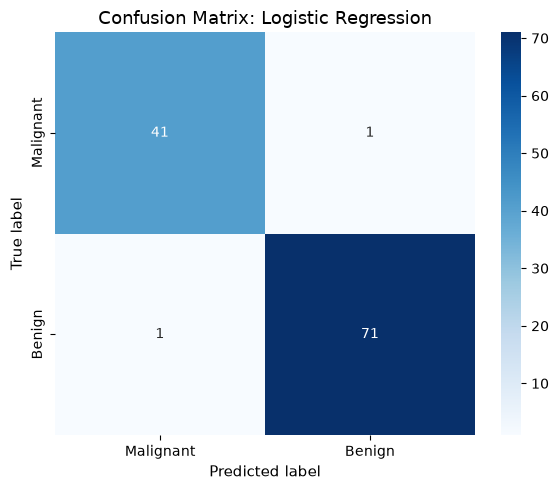

Confusion matrix saved.


In [24]:
# Create confusion matrix 
cm = confusion_matrix(y_test, y_pred) 
 
fig, ax = plt.subplots(figsize=(6, 5)) 
 
sns.heatmap( 
   cm, 
   annot=True, 
   fmt="d", 
   cmap="Blues", 
   xticklabels=["Malignant", "Benign"], 
   yticklabels=["Malignant", "Benign"], 
   ax=ax 
) 
 
ax.set_title("Confusion Matrix: Logistic Regression", fontsize=13) 
ax.set_xlabel("Predicted label", fontsize=11) 
ax.set_ylabel("True label", fontsize=11) 
 
plt.tight_layout() 
plt.savefig( 
   "../outputs/figures/confusion_matrix.png", 
   dpi=300 
) 
plt.show() 
 
print("Confusion matrix saved.")

In [25]:
# Save classification report as a DataFrame 
report_dict = classification_report( 
   y_test, 
   y_pred, 
   target_names=["Malignant", "Benign"], 
   output_dict=True 
) 
 
report_df = pd.DataFrame(report_dict).T 
 
report_df.to_csv( 
   "../outputs/tables/logistic_regression_classification_report.csv" 
) 
 
# Save accuracy summary 
accuracy_summary = pd.DataFrame({ 
   "metric": ["test_accuracy"], 
   "value": [round(accuracy, 4)] 
}) 
 
accuracy_summary.to_csv( 
   "../outputs/tables/model_accuracy_summary.csv", 
   index=False 
) 
 
print("Model evaluation results saved.") 
print() 
print(report_df) 


Model evaluation results saved.

              precision    recall  f1-score     support
Malignant      0.976190  0.976190  0.976190   42.000000
Benign         0.986111  0.986111  0.986111   72.000000
accuracy       0.982456  0.982456  0.982456    0.982456
macro avg      0.981151  0.981151  0.981151  114.000000
weighted avg   0.982456  0.982456  0.982456  114.000000


## Limitations and important notes 
 
- This is an educational demonstration using a historic public dataset first published in 1995. 
- The dataset contains 569 samples, which is small by modern machine-learning standards. 
- Logistic regression is a simple linear classifier. More complex models may perform differently. 
- The high accuracy on this dataset is well-known and reflects the separability of the features, not a novel finding. 
- These results must not be used for clinical decision-making, patient diagnosis, or medical advice. 
- A real clinical machine-learning workflow would require prospective validation, regulatory review, and ethical oversight. 
- Feature scaling was applied using parameters derived from the training set only, to avoid data leakage. 
- The train/test split used a fixed random seed for reproducibility. 


## Summary 
 
This notebook demonstrated an end-to-end exploratory data analysis and introductory  
classification workflow using the Breast Cancer Wisconsin (Diagnostic) dataset. 
 
### Key findings 
 
- The dataset contains 569 samples: 357 benign and 212 malignant. 
- No missing values were present in any feature column. 
- Malignant tumours showed consistently higher mean radius, perimeter, area,  
 and concavity compared to benign tumours. 
- Mean radius and mean perimeter were strongly correlated, as expected from  
 their geometric relationship. 
- A logistic regression classifier trained on 80% of the data achieved 98.25%  
 accuracy on the held-out 20% test set. 
- Both malignant and benign classes were classified with high precision and recall. 
 
### Workflow steps completed 
 
1. Loaded the dataset using scikit-learn. 
2. Created a pandas DataFrame and inspected data quality. 
3. Produced descriptive statistics. 
4. Visualised class distribution, key feature distributions,  
  feature correlations, and a scatter plot. 
5. Split data into training and test sets using stratified sampling. 
6. Standardised features using StandardScaler fitted on training data only. 
7. Trained a logistic regression classifier. 
8. Evaluated performance using accuracy, classification report,  
  and confusion matrix. 
9. Saved all outputs to structured project folders. 
 
### Limitations 
 
- Historic public dataset with 569 samples. 
- Results reflect known feature separability, not a novel discovery. 
- No cross-validation or hyperparameter tuning was performed. 
- Results must not be used for clinical decision-making. 
 

In [26]:
# Print a summary of all saved output files 
import os 
 
figures = os.listdir("../outputs/figures") 
tables = os.listdir("../outputs/tables") 
 
print("Saved figures:") 
for f in sorted(figures): 
   print(" -", f) 
 
print() 
print("Saved tables:") 
for t in sorted(tables): 
   print(" -", t) 


Saved figures:
 - class_distribution_barplot.png
 - confusion_matrix.png
 - key_features_boxplots.png
 - mean_features_correlation_heatmap.png
 - radius_vs_concavity_scatter.png

Saved tables:
 - class_distribution.csv
 - descriptive_statistics.csv
 - logistic_regression_classification_report.csv
 - model_accuracy_summary.csv
